##### top

# FMP modelling for Figure 3 (Cue stimulus)

This notebook runs Bayesian models on Datasets 3 (dataset with randomising cue stimulus) that is described in the article to assess interaction between perception and memory difficulty levels in the FMP and to assess the effect of cue stimulus. We fit the following formulas to mean score within the condition. Throughout the notebook, I use `task` as a term for memory difficulty levels (M, UD, FD-e), `difficulty` as a term for perceptual difficulty levels (1, 2, 3), `target_loc_simple` as a categorical label for morphing status of the cue stimulus (unmorphed = `target_0`, morphed = `other`), and `userID` as a variable denoting individual participants. It is the exact same principle and code as the `FMP_fit_linear_regression-Figure3-cue_stimulus.ipynb` but it sets the FM as a reference level instead of UD. The reference levels are FM level 1 with morphed cue stimulus.


* Model task and difficulty interaction with user as a random effect. Add to it interaction with cue stimulus. Equation:
    * _"correct_flt ~ task * difficulty + target_loc_simple * task + (1|userID)"_
    
* Model interaction between all three variables (task, difficulty, cue stimulus)
    * _"correct_flt ~ task * difficulty * target_loc_simple + (1|userID)"_

* Model task and difficulty interaction with user as a random effect. Equation:
    * _correct_flt ~ task * difficulty + (1|userID)_
* Model task and difficulty as main effects without interaction with user as a random effect. Equation:
    * _correct_flt ~ task + difficulty + (1|userID)_



We model mean accuracy per participant per condition.


* [Models](#Models)
* [Plot results](#Plot-results)
* [Compare all data](#Compare-all-data)
* [Save the inference](#Save-the-inference)


In [1]:
import os, sys
import pickle
from os.path import join as opj
import arviz as az
import bambi as bmb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

az.style.use("arviz-darkgrid")
SEED = 7355608


# Importing module for functions
functions_modul =  "./functions"
sys.path.insert(0, functions_modul)

# import all processing and plotting functions
from bayesian_modelling_functions import fit_model, print_model

path_general = "../"
path_data = opj(path_general, "Data", "datasets")
path_inference_data = opj(path_general, "Data", "model_inference_data")


# set the numer of CPU
num_cpu = min(4, os.cpu_count()-1)
print(f'We will have {num_cpu} cores.\n')


path_dic = {
#     'dataset_1' : opj(path_data, 'FMP_dataset_1.csv'),
#     'dataset_2': opj(path_data, 'FMP_dataset_2.csv'),
    'dataset_3': opj(path_data, 'FMP_dataset_3.csv'),
#     'concat_datasets_123': opj(path_data, 'FMP_concat_datasets_123.csv'),
#     'dataset_4': opj(path_data, 'FMP_dataset_4.csv'),
}


#####
# rename the levels
rename_tasks_dic = {'perception':'Matching', 'perc':'Matching', 'blank':'Unfilled Delay', 'faces':'Filled Delay - emotions', 'math':'Filled Delay - math'}

# define orders
hue_order = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions']
hue_order_math = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions', 'Filled Delay - math']


# load 
df_dataset_3 = pd.read_csv(opj(path_data, 'FMP_dataset_3.csv'))
# groupby and make means for ptc and condition
data = df_dataset_3.groupby(['userID', 'task', 'difficulty']).correct_flt.mean().reset_index()

# convert all variables to categories
# categorical_cols = data.columns[data.dtypes == object].tolist() + ['difficulty']
categorical_cols = ['userID', 'task', 'difficulty']
for col in categorical_cols:
    if col == 'task':
        # specify the order that we want
        data[col] = pd.Categorical(data[col], categories=['Unfilled Delay', 'Matching', 'Filled Delay - emotions'], ordered=True)
        #['Unfilled Delay', 'Matching', 'Filled Delay - emotions']

        # also do it for the original datasets
        df_dataset_3[col] = pd.Categorical(df_dataset_3[col], categories=['Unfilled Delay', 'Matching', 'Filled Delay - emotions'], ordered=True)

    else:
        data[col] = data[col].astype("category")
        df_dataset_3[col] = df_dataset_3[col].astype("category")
data.info()

data.describe()
# data.dtypes


We will have 4 cores.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2358 entries, 0 to 2357
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   userID       2358 non-null   category
 1   task         2358 non-null   category
 2   difficulty   2358 non-null   category
 3   correct_flt  2343 non-null   float64 
dtypes: category(3), float64(1)
memory usage: 38.2 KB


,correct_flt
count,2343.000000
mean,0.757969
std,0.147381
min,0.250000
25%,0.650000
50%,0.764706
75%,0.850000
max,1.000000


In [2]:
# drop them for now
data[data.correct_flt.isna()]

,userID,task,difficulty,correct_flt
9,s_1001,Filled Delay - emotions,1,NaN
10,s_1001,Filled Delay - emotions,2,NaN
11,s_1001,Filled Delay - emotions,3,NaN
675,s_314,Filled Delay - emotions,1,NaN
676,s_314,Filled Delay - emotions,2,NaN
677,s_314,Filled Delay - emotions,3,NaN
918,s_408,Filled Delay - emotions,1,NaN
919,s_408,Filled Delay - emotions,2,NaN
920,s_408,Filled Delay - emotions,3,NaN
1836,s_791,Filled Delay - emotions,1,NaN


## Models
[top](#top)

In [3]:
model_assumptions = {
    "correct_flt ~ task * difficulty + (1|userID)": "Each user has their own baseline performance, but the effect of task and difficulty is assumed to be the same across all users.",
    "correct_flt ~ task + difficulty + (1|userID)": "Assumes that each user has their own baseline performance, but the effects of task and difficulty are consistent across all users without any interaction between task and difficulty.",
    "correct_flt ~ task * difficulty * target_loc_simple + (1|userID)": "Assumes that each user has their own baseline performance (random intercept), while the effects of task, difficulty, and target location (including all interactions between them) are consistent across all users.",
    "correct_flt ~ task * difficulty + target_loc_simple * task + (1|userID)":"Assumes that each user has their own baseline performance (random intercept), while the effects of task, difficulty, and the interaction between task and target location are consistent across all users. The interaction between task and difficulty is also considered, but target location only interacts with task, not difficulty.",
}

# define what we want to run
base_lvl = ['Matching', 'Unfilled Delay', 'Filled Delay - emotions']
formulas2run = [
#     "correct_flt ~ C(task, levels=base_lvl) * difficulty * target_loc_simple + (1|userID)"
#     "correct_flt ~ C(task, levels=base_lvl) * difficulty + target_loc_simple * C(task, levels=base_lvl) + (1|userID)",
    "correct_flt ~ C(task, levels=base_lvl) * difficulty + (1|userID)",
    "correct_flt ~ C(task, levels=base_lvl) + difficulty + (1|userID)",
]



In [4]:
# define where we will store the results
model_dic = {}
result_dic = {}

for formula in formulas2run:
    print(f'\nFitting formula {formula}\n-> {model_assumptions[formula.replace('C(task, levels=base_lvl)','task')]}\n')
    
    model_dic[formula], result_dic[formula] = fit_model(formula, data, categorical_cols, base_lvl=base_lvl,
                                                        num_cpu=num_cpu, check_priors=False, sample_priors=False)
    
    
    
#     print('\n------------------------')

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:20

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.


In [5]:
# add the target loc
formula = "correct_flt ~ C(task, levels=base_lvl) * difficulty + target_loc_simple * C(task, levels=base_lvl) + (1|userID)"
    
model_dic[formula], result_dic[formula] = fit_model(formula, 
                                                    data=df_dataset_3.groupby(['userID', 'task', 'difficulty', 'target_loc_simple']).correct_flt.mean().reset_index(), 
                                                    categorical_cols = ['userID', 'task', 'difficulty', 'target_loc_simple'],
                                                    base_lvl=base_lvl,
                                                    # increase the tuning a little bit to help R_hat
                                                    fit_kwargs={"tune":1300},
                                  check_priors=False, sample_priors=False, num_cpu=num_cpu)

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:44

Sampling 4 chains for 1_300 tune and 1_000 draw iterations (5_200 + 4_000 draws total) took 45 seconds.


In [6]:
# add full interaction
formula = "correct_flt ~ C(task, levels=base_lvl) * difficulty * target_loc_simple + (1|userID)"

    
model_dic[formula], result_dic[formula] = fit_model(formula, 
                                                    data=df_dataset_3.groupby(['userID', 'task', 'difficulty', 'target_loc_simple']).correct_flt.mean().reset_index(), 
                                                    categorical_cols = ['userID', 'task', 'difficulty', 'target_loc_simple'],
                                                    base_lvl=base_lvl,
                                  check_priors=False, sample_priors=False, num_cpu=num_cpu)

Sampling 4 chains, 0 divergences ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:49

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 49 seconds.


In [7]:
model_dic["correct_flt ~ C(task, levels=base_lvl) * difficulty * target_loc_simple + (1|userID)"]

       Formula: correct_flt ~ C(task, levels=base_lvl) * difficulty * target_loc_simple + (1|userID)
        Family: gaussian
          Link: mu = identity
  Observations: 4685
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.7496, sigma: 1.2346)
            C(task, levels=base_lvl) ~ Normal(mu: [0. 0.], sigma: [1.1122 1.1178])
            difficulty ~ Normal(mu: [0. 0.], sigma: [1.1142 1.114 ])
            C(task, levels=base_lvl):difficulty ~ Normal(mu: [0. 0. 0. 0.], sigma: [1.6663 1.6663 1.6818
                1.6804])
            target_loc_simple ~ Normal(mu: 0.0, sigma: 1.0503)
            C(task, levels=base_lvl):target_loc_simple ~ Normal(mu: [0. 0.], sigma: [1.4055 1.4163])
            difficulty:target_loc_simple ~ Normal(mu: [0. 0.], sigma: [1.4091 1.4091])
            C(task, levels=base_lvl):difficulty:target_loc_simple ~ Normal(mu: [0. 0. 0. 0.], sigma: [2.2856
                2.2856 2.3064 2.3064])
        
        
    


Printing formula correct_flt ~ C(task, levels=base_lvl) * difficulty + (1|userID)
-> Each user has their own baseline performance, but the effect of task and difficulty is assumed to be the same across all users.



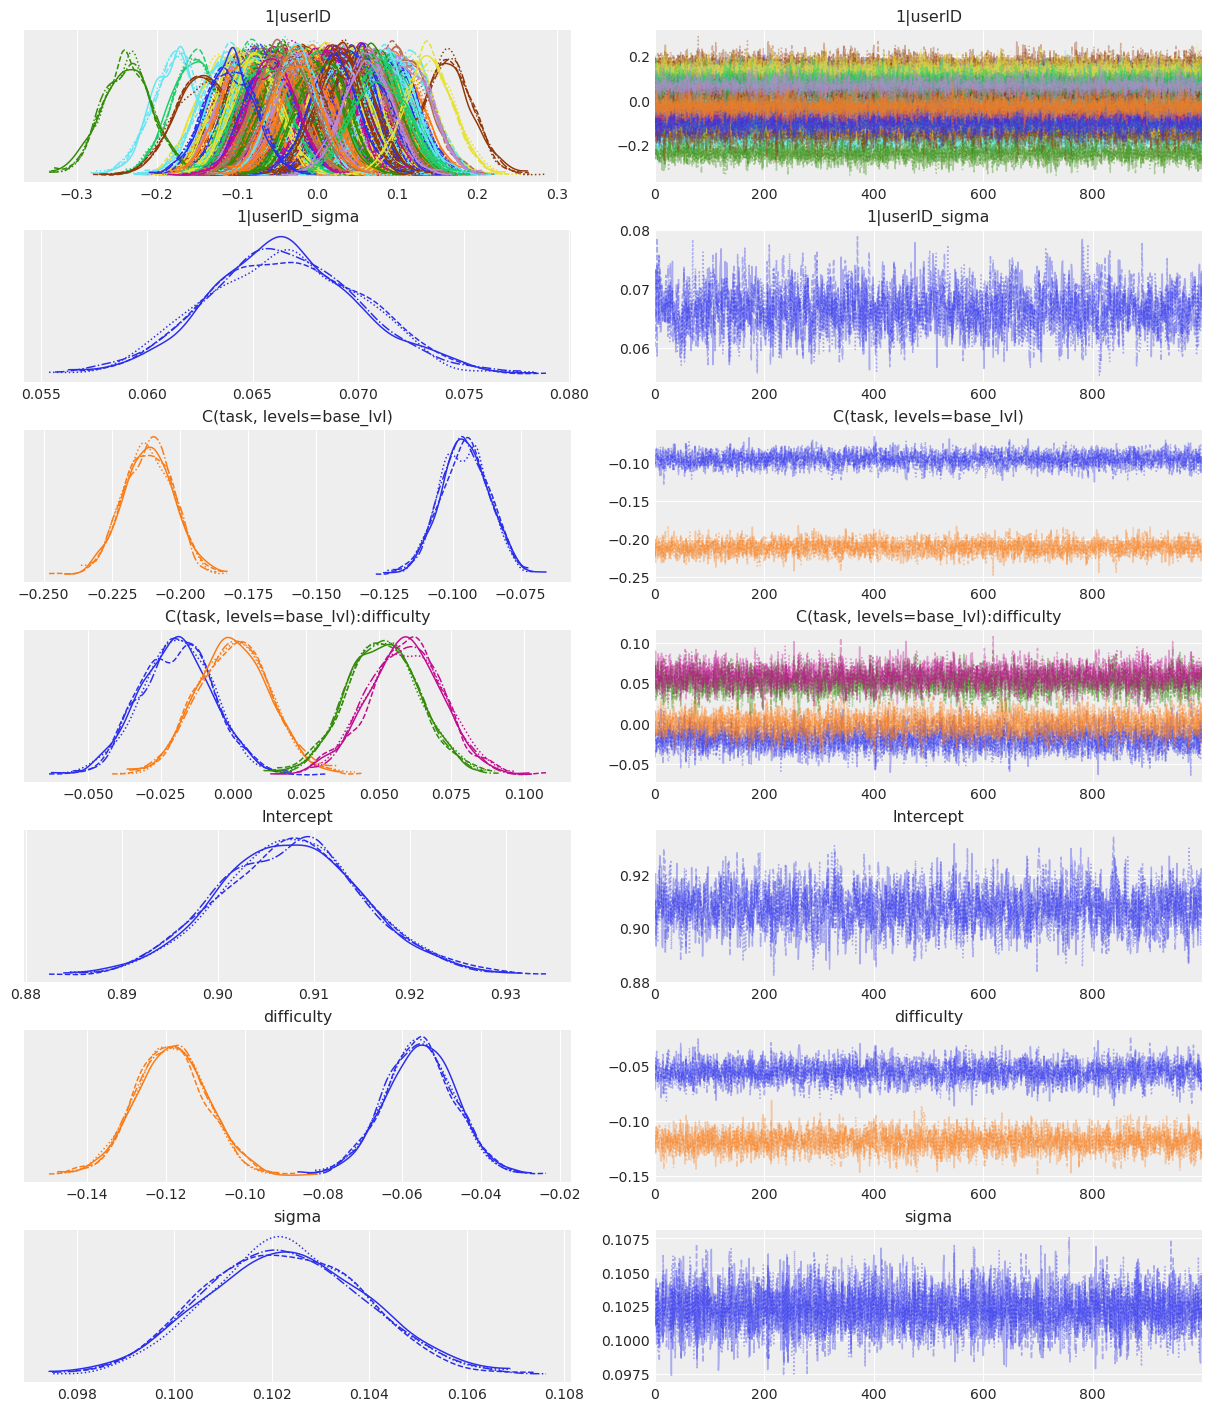

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1000]  0.023  0.031  -0.031    0.085        0.0    0.000    8661.0   
1|userID[s_1001]  0.004  0.036  -0.062    0.070        0.0    0.001    7544.0   
1|userID[s_1002] -0.097  0.031  -0.156   -0.042        0.0    0.000    7879.0   
1|userID[s_1004] -0.027  0.030  -0.082    0.032        0.0    0.000    8712.0   
1|userID[s_1019] -0.087  0.030  -0.141   -0.028        0.0    0.000    6611.0   
1|userID[s_1021] -0.051  0.031  -0.114    0.002        0.0    0.000    6970.0   
1|userID[s_1023]  0.048  0.030  -0.011    0.103        0.0    0.000    8096.0   
1|userID[s_1028]  0.080  0.030   0.029    0.140        0.0    0.000    7842.0   
1|userID[s_1029]  0.010  0.032  -0.048    0.073        0.0    0.001    9594.0   
1|userID[s_105]   0.064  0.032   0.006    0.123        0.0    0.000    8429.0   
1|userID[s_1054] -0.068  0.031  -0.127   -0.009        0.0    0.000   10010.0   
1|userID[s_1064]  0.102  0.0

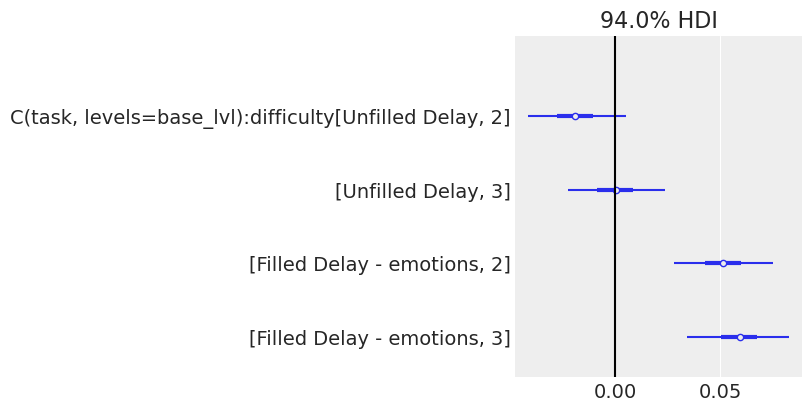

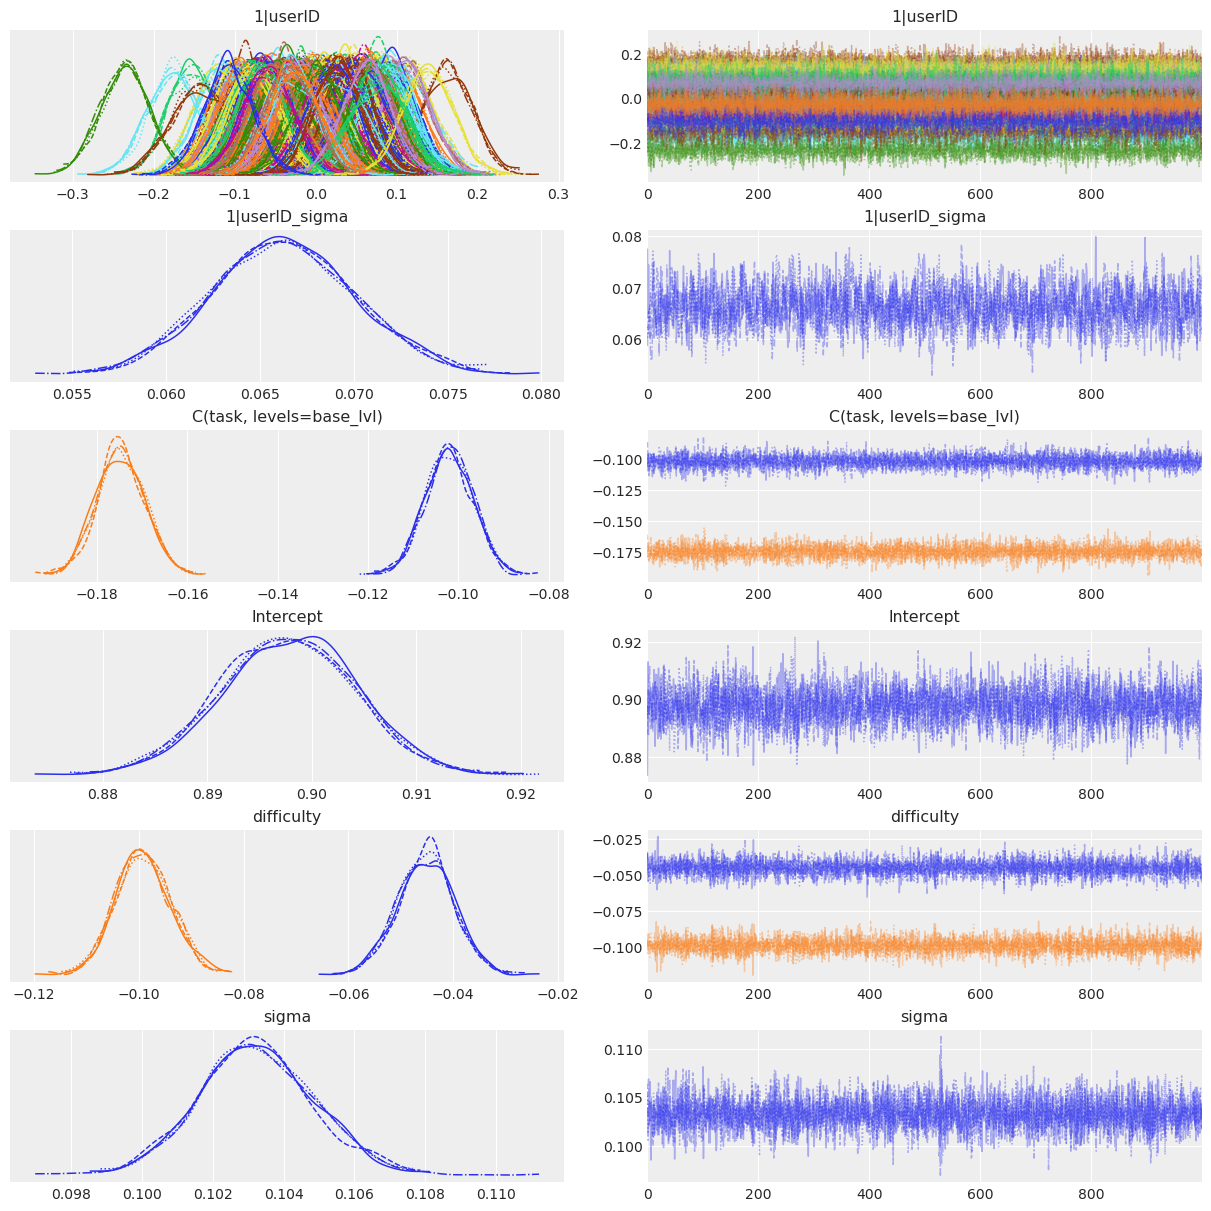

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1000]  0.023  0.031  -0.034    0.081        0.0    0.000    6704.0   
1|userID[s_1001]  0.004  0.036  -0.064    0.070        0.0    0.001    8093.0   
1|userID[s_1002] -0.096  0.031  -0.154   -0.036        0.0    0.000    7667.0   
1|userID[s_1004] -0.028  0.031  -0.083    0.032        0.0    0.000    7084.0   
1|userID[s_1019] -0.086  0.030  -0.141   -0.031        0.0    0.000    6283.0   
1|userID[s_1021] -0.051  0.031  -0.108    0.005        0.0    0.000    7422.0   
1|userID[s_1023]  0.048  0.031  -0.010    0.103        0.0    0.000    8281.0   
1|userID[s_1028]  0.079  0.029   0.026    0.136        0.0    0.000    6509.0   
1|userID[s_1029]  0.010  0.031  -0.049    0.066        0.0    0.001    7066.0   
1|userID[s_105]   0.064  0.031   0.008    0.122        0.0    0.000    7175.0   
1|userID[s_1054] -0.067  0.031  -0.125   -0.007        0.0    0.000    7227.0   
1|userID[s_1064]  0.101  0.0

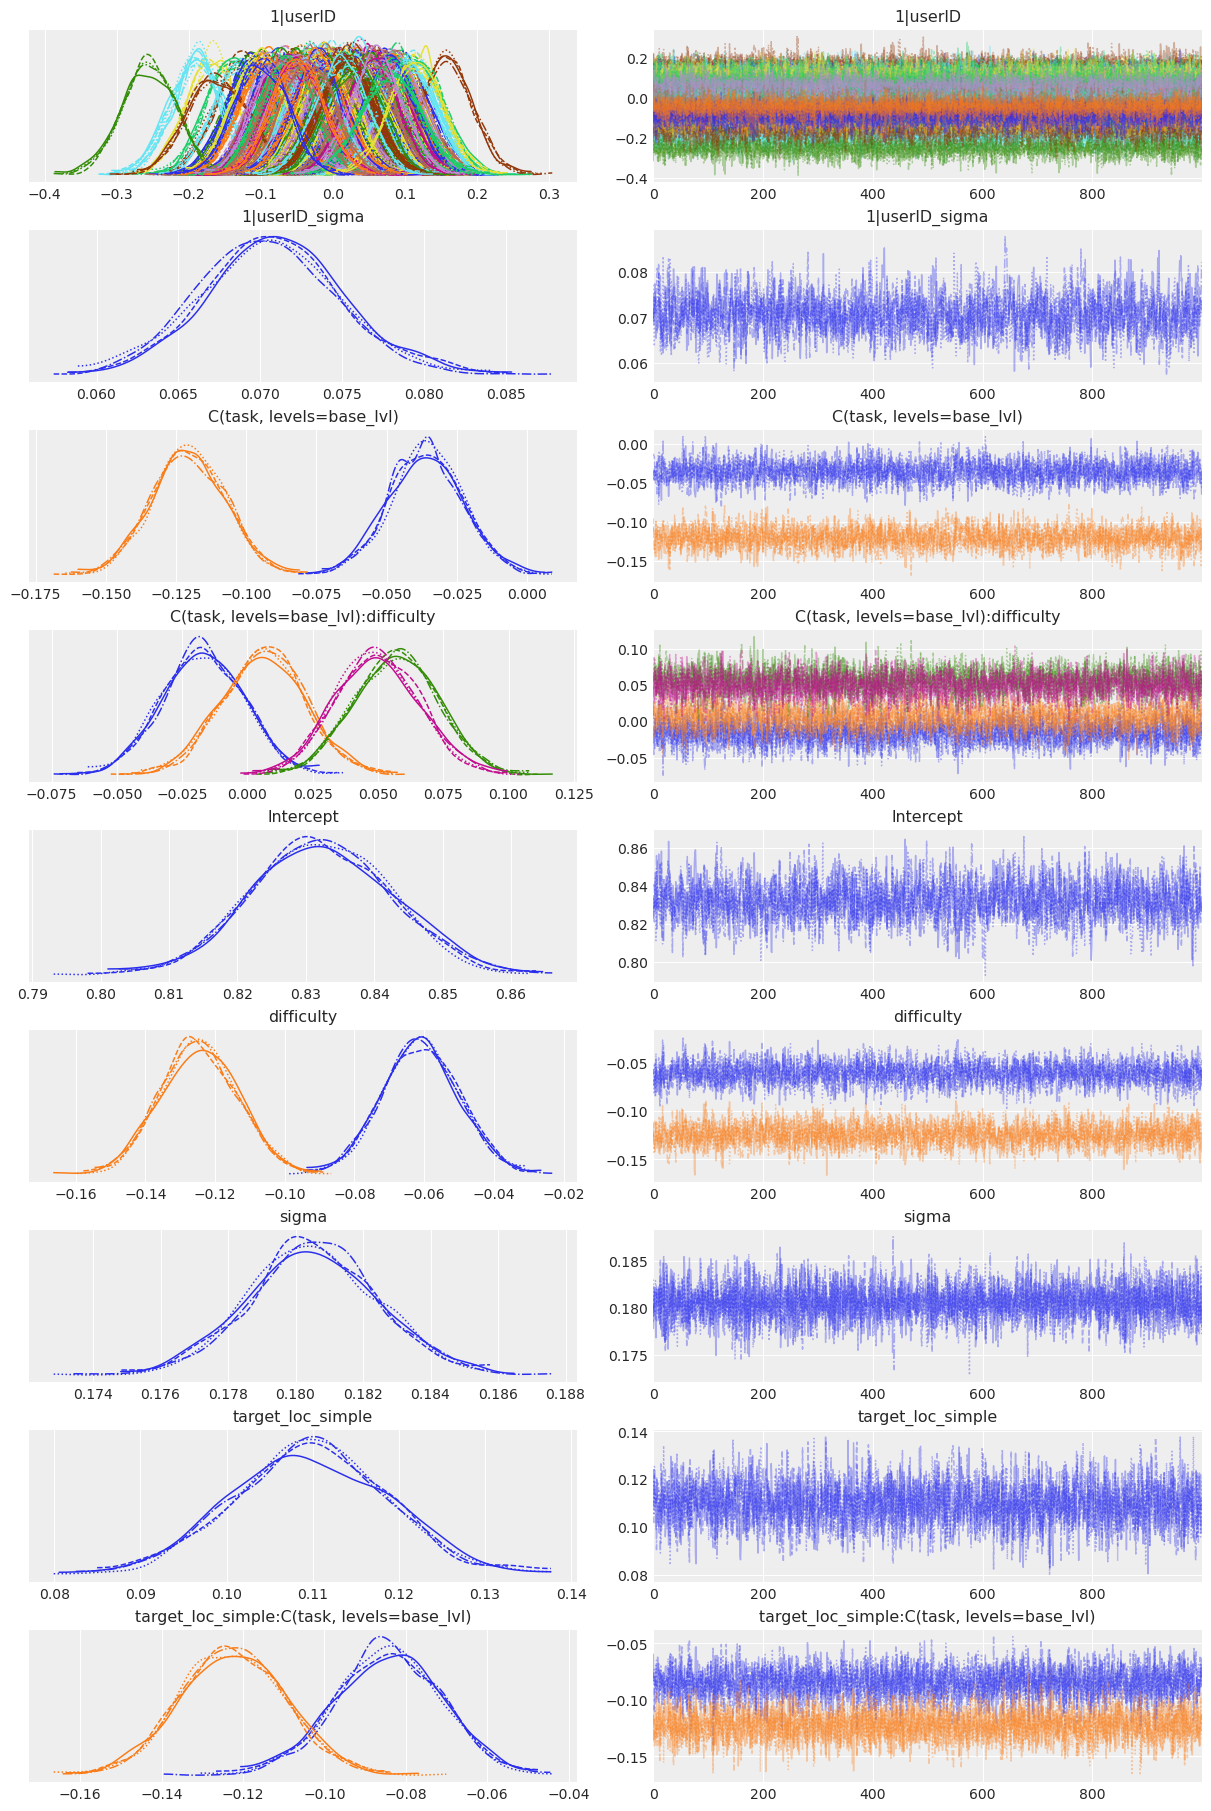

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1000]  0.028  0.038  -0.045    0.096        0.0    0.001    7854.0   
1|userID[s_1001]  0.011  0.041  -0.069    0.084        0.0    0.001    7770.0   
1|userID[s_1002] -0.112  0.035  -0.180   -0.047        0.0    0.000    8274.0   
1|userID[s_1004] -0.033  0.035  -0.098    0.034        0.0    0.000    8445.0   
1|userID[s_1019] -0.042  0.037  -0.113    0.025        0.0    0.000    9648.0   
1|userID[s_1021] -0.018  0.036  -0.084    0.048        0.0    0.001    7970.0   
1|userID[s_1023]  0.048  0.036  -0.022    0.115        0.0    0.000    8814.0   
1|userID[s_1028]  0.051  0.037  -0.019    0.118        0.0    0.000    6837.0   
1|userID[s_1029]  0.009  0.038  -0.060    0.081        0.0    0.001    8245.0   
1|userID[s_105]   0.068  0.037  -0.002    0.135        0.0    0.000    7703.0   
1|userID[s_1054] -0.055  0.037  -0.130    0.008        0.0    0.000    7913.0   
1|userID[s_1064]  0.094  0.0

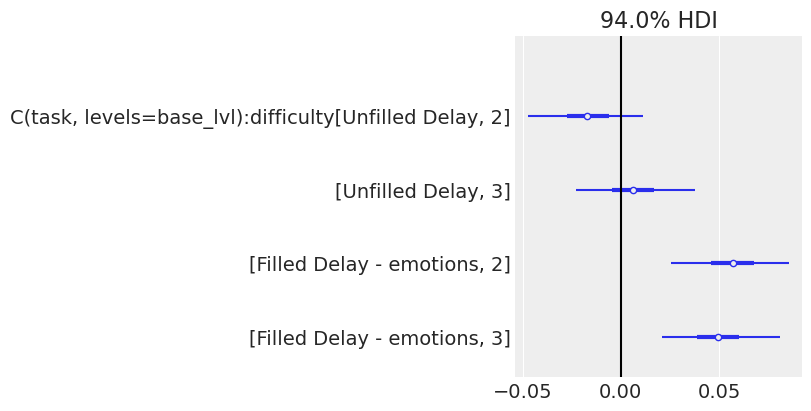

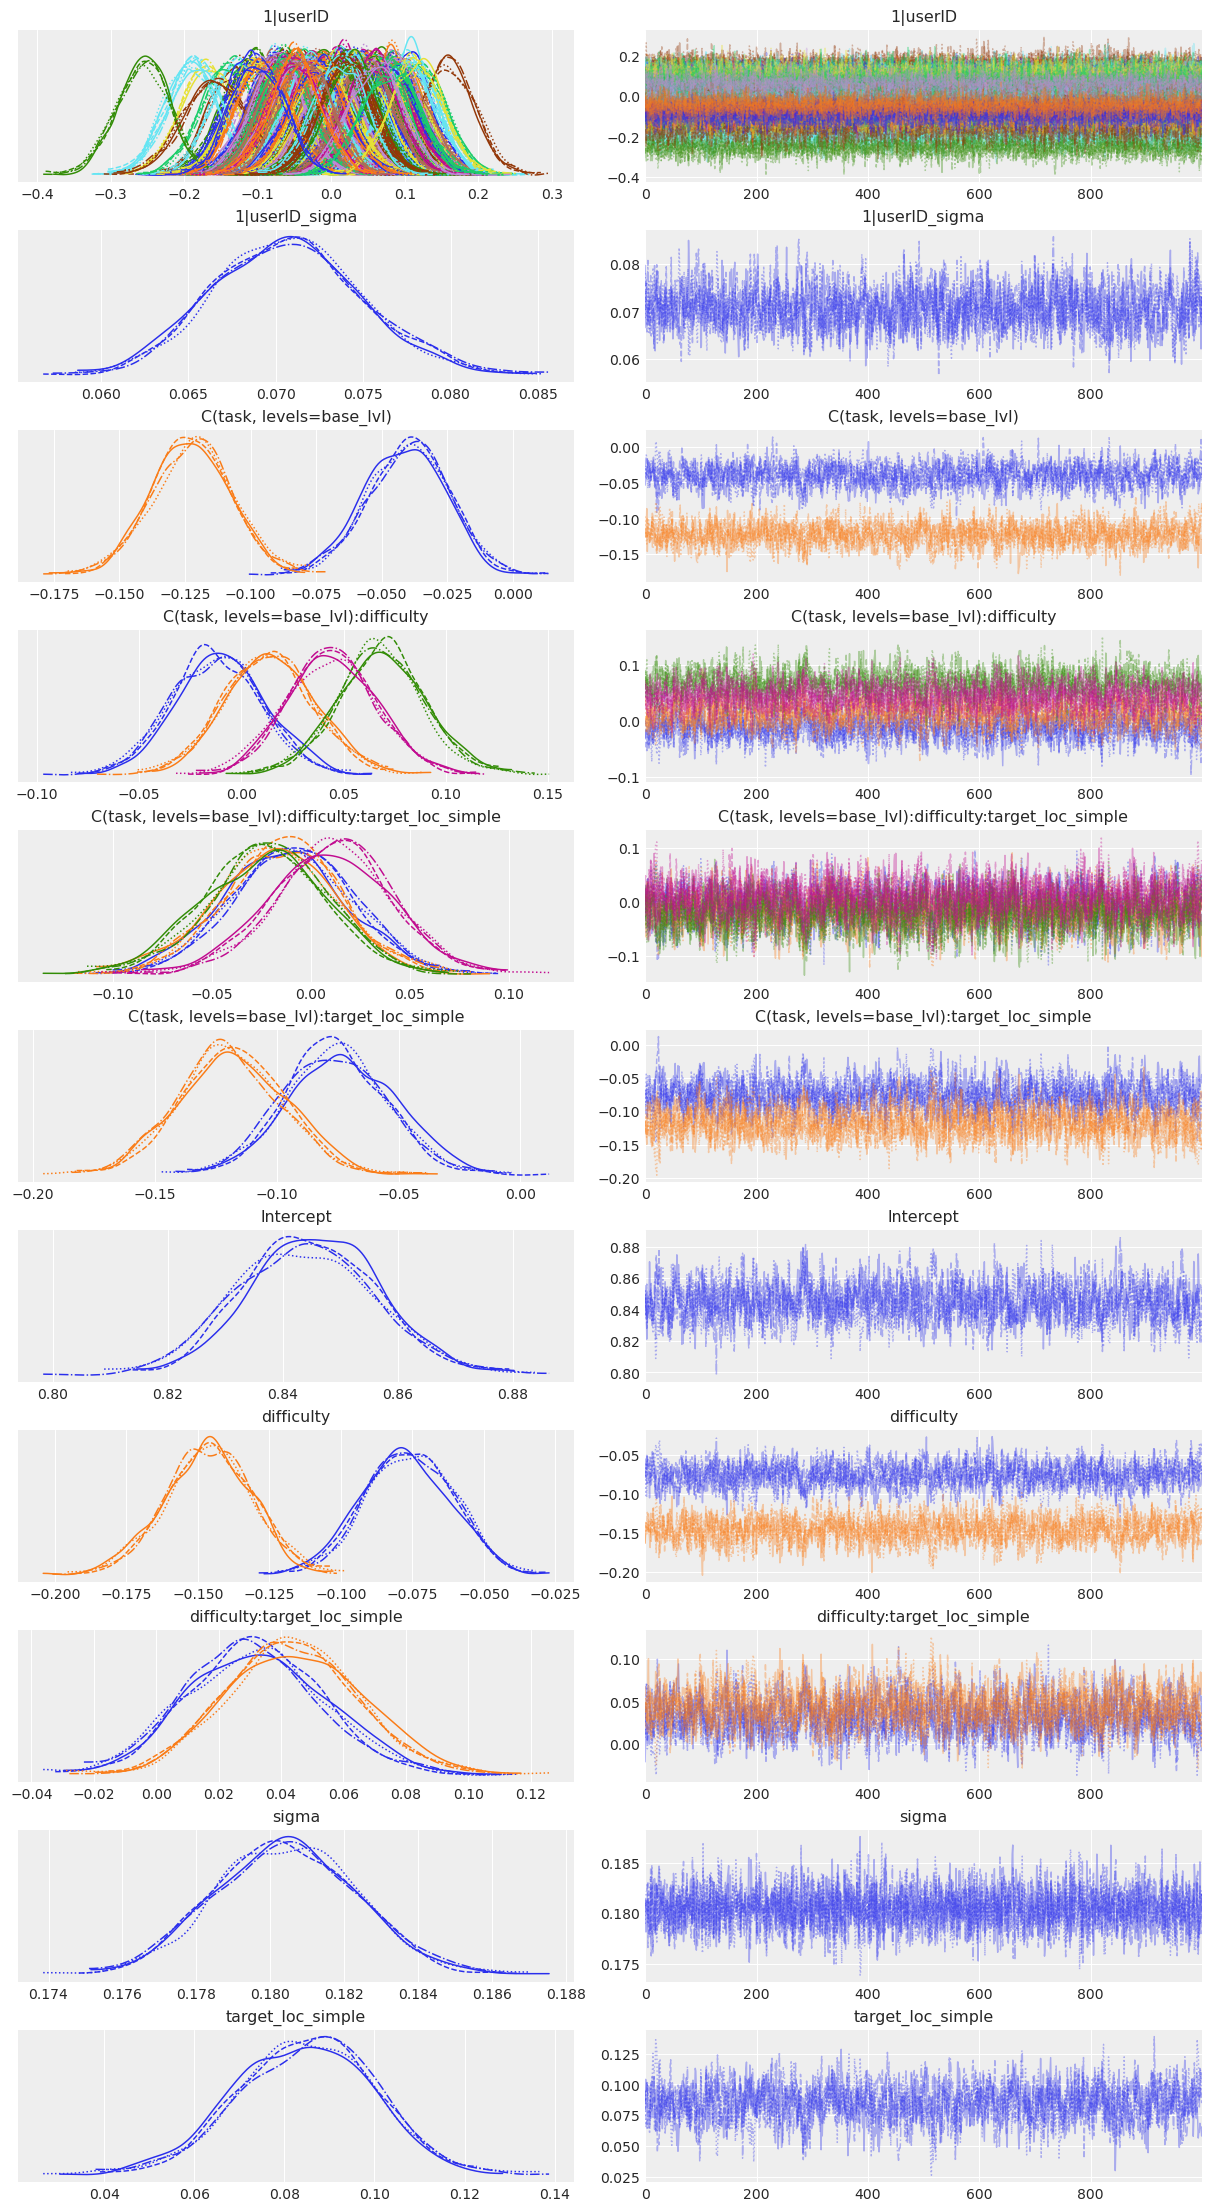

                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
1|userID[s_1000]  0.029  0.037  -0.044    0.093      0.001    0.000    4958.0   
1|userID[s_1001]  0.011  0.042  -0.066    0.092      0.001    0.001    5355.0   
1|userID[s_1002] -0.113  0.037  -0.182   -0.043      0.001    0.000    5198.0   
1|userID[s_1004] -0.034  0.038  -0.105    0.037      0.001    0.000    4167.0   
1|userID[s_1019] -0.043  0.036  -0.109    0.026      0.001    0.000    4742.0   
1|userID[s_1021] -0.018  0.036  -0.082    0.052      0.001    0.001    4855.0   
1|userID[s_1023]  0.048  0.037  -0.016    0.121      0.001    0.000    4205.0   
1|userID[s_1028]  0.051  0.036  -0.015    0.120      0.001    0.000    4235.0   
1|userID[s_1029]  0.010  0.036  -0.058    0.081      0.001    0.001    4140.0   
1|userID[s_105]   0.067  0.036  -0.001    0.135      0.001    0.000    4473.0   
1|userID[s_1054] -0.055  0.039  -0.125    0.021      0.001    0.000    3989.0   
1|userID[s_1064]  0.094  0.0

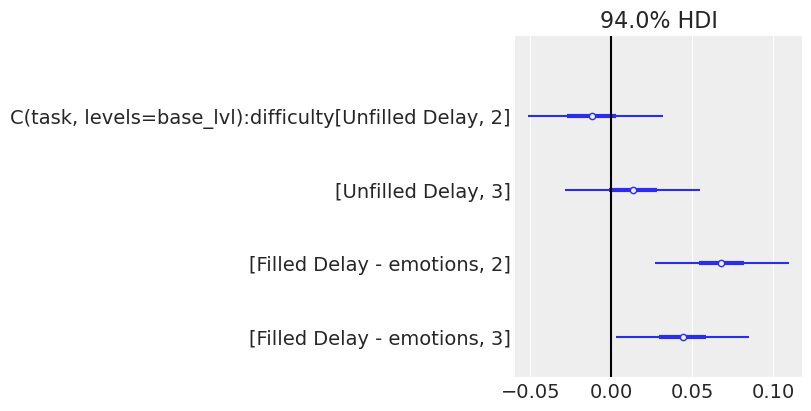

In [8]:
# print the model

for formula in list(model_dic.keys()):
    print(f'\nPrinting formula {formula}\n-> {model_assumptions[formula.replace('C(task, levels=base_lvl)', 'task')]}\n')

    print_model(model_dic[formula], result_dic[formula])
    
    print('\n------------------------')

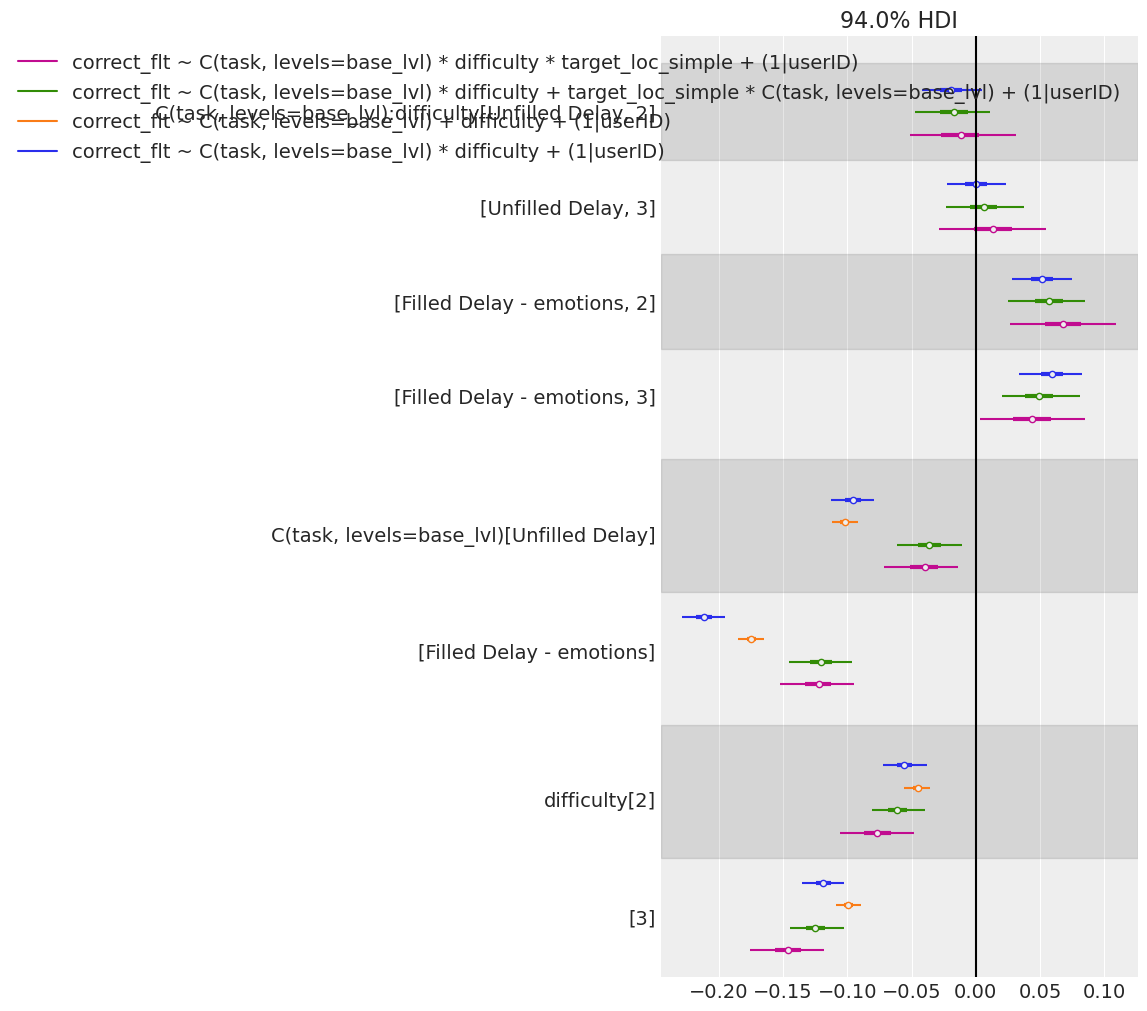

In [9]:
az.plot_forest(
    list(result_dic.values()),
    model_names=list(model_dic.keys()), 
    var_names=["C(task, levels=base_lvl):difficulty", "C(task, levels=base_lvl)", "difficulty"],
    combined=True,
    figsize=(11, 10),
)

plt.axvline(0, c='k');

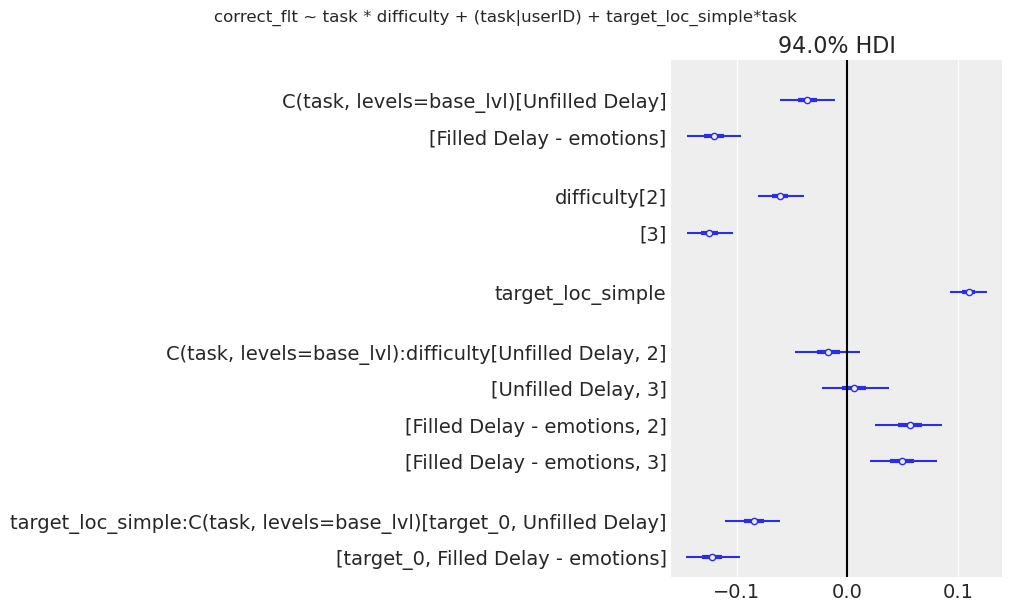

In [10]:
az.plot_forest(
    result_dic['correct_flt ~ C(task, levels=base_lvl) * difficulty + target_loc_simple * C(task, levels=base_lvl) + (1|userID)'],
#     model_names=['correct_flt ~ task * difficulty + (task|userID) + target_loc_simple*task'],#list(model_assumptions.keys()),
    var_names=["C(task, levels=base_lvl)", "difficulty", "target_loc_simple", "C(task, levels=base_lvl):difficulty", "target_loc_simple:C(task, levels=base_lvl)"],
    combined=True,
    figsize=(10, 6),
)

plt.axvline(0, c='k')

plt.suptitle('correct_flt ~ task * difficulty + (task|userID) + target_loc_simple*task');


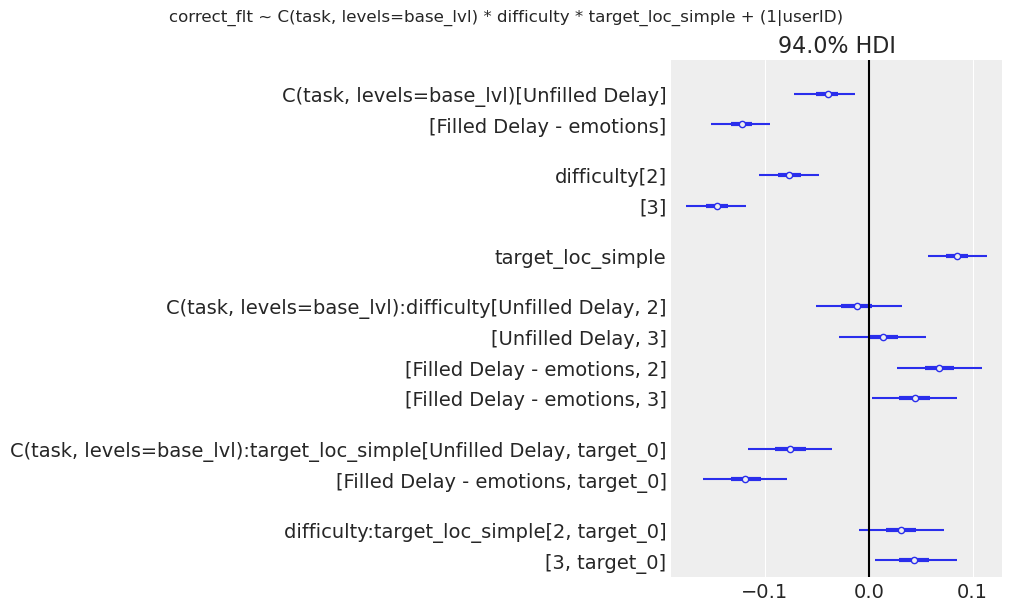

In [11]:
formula = 'correct_flt ~ C(task, levels=base_lvl) * difficulty * target_loc_simple + (1|userID)'
az.plot_forest(
    result_dic[formula],
#     model_names=['correct_flt ~ task * difficulty + (task|userID) + target_loc_simple*task'],#list(model_assumptions.keys()),
    var_names=["C(task, levels=base_lvl)", "difficulty", "target_loc_simple", "C(task, levels=base_lvl):difficulty", "C(task, levels=base_lvl):target_loc_simple", "difficulty:target_loc_simple"],
    combined=True,
    figsize=(10, 6),
)

plt.axvline(0, c='k')

plt.suptitle(f'{formula}');


### Compare all data
[top](#top)

In [12]:

new_results = {}
for f in result_dic.keys():
#     if f!='correct_flt ~ task * difficulty + (task|userID) + target_loc_simple*task':
    if f!='correct_flt ~ C(task, levels=base_lvl) * difficulty + target_loc_simple * C(task, levels=base_lvl) + (1|userID)' and f!='correct_flt ~ C(task, levels=base_lvl) * difficulty * target_loc_simple + (1|userID)':
        new_results[f] = result_dic[f]

df_compare_formulas = az.compare(new_results)
df_compare_formulas



,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
"correct_flt ~ C(task, levels=base_lvl) * difficulty + (1|userID)",0,1905.793165,207.252828,0.000000,0.87593,35.326966,0.00000,False,log
"correct_flt ~ C(task, levels=base_lvl) + difficulty + (1|userID)",1,1885.739112,203.286361,20.054053,0.12407,35.645477,7.32397,False,log


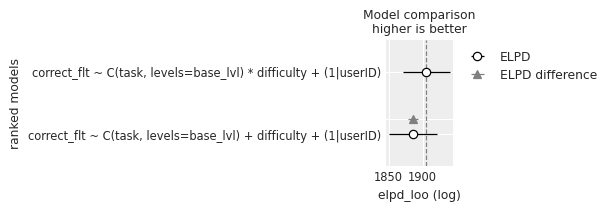

In [13]:
az.plot_compare(df_compare_formulas, insample_dev=False);

### Save the inference
[top](#top)


In [14]:

# save the dictionary to a pickle file
with open(opj(path_inference_data,'FMP_cue_stimulus_baselineFM_inference_data_dict.pkl'), 'wb') as f:
    pickle.dump(result_dic, f)

# # Load the dictionary from the pickle file
# with open(opj(path_inference_data,'FMP_cue_stimulus_baselineFM_inference_data_dict.pkl'), 'rb') as f:
#     loaded_inference_data_dict = pickle.load(f)


In [15]:
%load_ext watermark

%watermark -a 'Jan Kadlec' -nmvu -iv -iv -w -p pytensor


Author: Jan Kadlec

Last updated: Wed Feb 05 2025

Python implementation: CPython
Python version       : 3.12.5
IPython version      : 8.25.0

pytensor: 2.23.0

Compiler    : GCC 12.4.0
OS          : Linux
Release     : 5.14.0-427.42.1.el9_4.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 96
Architecture: 64bit

bambi     : 0.14.0
numpy     : 1.26.4
matplotlib: 3.9.2
arviz     : 0.19.0
pandas    : 2.2.2
sys       : 3.12.5 | packaged by conda-forge | (main, Aug  8 2024, 18:36:51) [GCC 12.4.0]

Watermark: 2.4.3



[top](#top)